# Offline CV-RAG Results with Photorealistic Incident Context

This notebook is the full-offline scenario: the device has a local image/text case pack, photorealistic construction-site image assets, local CLIP embeddings, a SQLite vector store, and local answer drafting from retrieved evidence. The incident text was generated with the `gpt-5.4-mini` deployment; the current image pack was generated through Azure OpenAI `gpt-image-1.5` using the official `images/generations` API.


## Local model path clarification

| Stage | Current implementation in this VM POC |
| --- | --- |
| Query vectorization | `openai/clip-vit-base-patch32` runs locally and embeds both the worker text and the query image when `query_mode=image-text`. |
| Vector search | SQLite stores fused CLIP image/text vectors for cached cases and returns the closest evidence. |
| Answer drafting | `Phi-4-mini-instruct` is text-only, so it receives the retrieved evidence as text. It is not directly given pixels. |
| Executed notebook generator | `template`. Use `--generator phi4` to attempt the actual local Phi-4-mini text model after weights are cached; this VM run used the deterministic fallback when set to `template`. |
| Direct image+text SLM option | Use `Phi-4-multimodal-instruct` if the SLM itself must inspect the image alongside the text prompt. |


## What got indexed into the local vector store

The offline pack contains only the six `offline_seed_enriched` records. Each incident image is cached in the local pack and indexed together with the incident text. The vector stored in SQLite is the same fused representation used by the runtime: `0.45 * image_embedding + 0.55 * incident_text_embedding`. This POC weighting favors text-only field queries while retaining visual grounding from the cached photo.

| ID | Severity | Visual clues | Root-cause hypothesis |
| --- | --- | --- | --- |
| INC-001 | high | Dark damp streaks on cast wall surface, Visible drips at construction joint, Efflorescence near joint line, Localized puddling at wall base | Likely discontinuity in waterproofing membrane, inadequate joint preparation, or failed waterstop/sealant at a construction joint combined with hydrostatic pressure. |
| INC-002 | high | Exposed coarse aggregate, Voids and honeycombed surface texture, Minor grout leakage marks, Irregular finish at column corner | Probable inadequate vibration, congested reinforcement impeding flow, grout loss through formwork joints, or improper concrete placement technique. |
| INC-003 | medium | Closely spaced longitudinal bars, Crowded stirrups and ties, Reduced clear space for concrete flow, Difficulty aligning cover blocks or spacers | Likely a combination of design-dense reinforcement at a highly loaded joint and insufficient constructability coordination between structural detailing and placement method. |
| INC-004 | medium | Duct occupies intended ceiling zone, Adjacent services have minimal clearance, Hangers and supports appear tightly packed, Potential conflict with lighting or access panels | Likely incomplete coordination of MEP trades, late design revisions, or insufficient clash detection before installation. |
| INC-005 | critical | Open edge without top rail or mid-rail, Scaffold access ladder or landing nearby, No visible toe board at edge, Exposure to drop zone below | Likely removal or omission of edge protection during sequencing, inadequate supervision, or incomplete scaffold-to-structure interface controls. |
| INC-006 | medium | Fine line crack near corner, No visible offset between surfaces, Localized around opening or stress concentration, No active leakage or spalling apparent | Possible shrinkage crack, restraint from adjacent pours, temporary load transfer effects, or stress concentration at an opening corner. |


Indexed offline case images 
 
 INC-001 - Basement wall water ingress observed at construction joint Severity: high Dark damp streaks on cast wall surface, Visible drips at construction joint, Efflorescence near joint line, Localized puddling at wall base 
 INC-002 - Concrete column honeycombing detected after form removal Severity: high Exposed coarse aggregate, Voids and honeycombed surface texture, Minor grout leakage marks, Irregular finish at column corner 
 INC-003 - Rebar congestion visible at beam-column joint Severity: medium Closely spaced longitudinal bars, Crowded stirrups and ties, Reduced clear space for concrete flow, Difficulty aligning cover blocks or spacers 
 INC-004 - MEP duct coordination clash at ceiling void Severity: medium Duct occupies intended ceiling zone, Adjacent services have minimal clearance, Hangers and supports appear tightly packed, Potential conflict with lighting or access panels 
 INC-005 - Unsafe open edge adjacent to scaffold access point Severity: critical Open edge without top rail or mid-rail, Scaffold access ladder or landing nearby, No visible toe board at edge, Exposure to drop zone below 
 INC-006 - Hairline crack observed near lift core wall opening Severity: medium Fine line crack near corner, No visible offset between surfaces, Localized around opening or stress concentration, No active leakage or spalling apparent
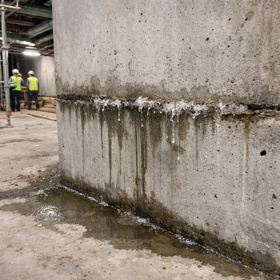
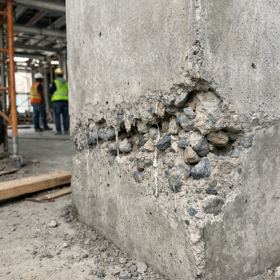
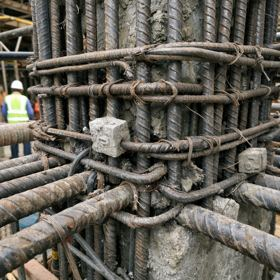
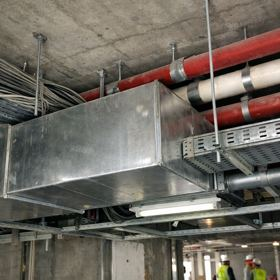
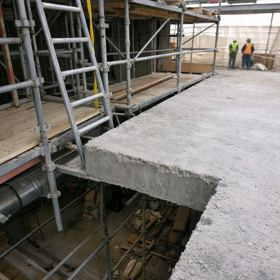
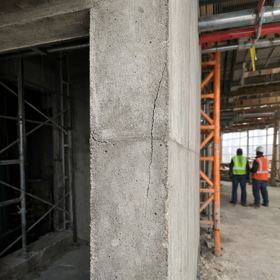

In [1]:
from IPython.display import HTML, display
# Executed output below embeds image thumbnails directly; it does not depend on relative Markdown image links.
display(HTML(indexed_case_gallery_html))


## Local vector store shape

| Field | Meaning |
| --- | --- |
| `incident_id` | Stable citation ID returned to Phi-4-mini and shown to the worker. |
| `payload_json` | Enriched incident title, severity, observation, visual clues, root-cause hypothesis, checklist, and escalation rule. |
| `image_path` | Photorealistic image cached in the offline pack. |
| `vector_json` | 512-dimensional CLIP fused image/text vector for the prototype; production should replace JSON vectors with `sqlite-vec` or USearch. |


## Offline query results

Each worker question is paired with a query photo from the test fixture. CLIP embeds the text and image locally, compares the fused vector against SQLite, and passes only the retrieved evidence to the answer generator.

| Scenario | Query inputs | Expected | Top hit | Matched | Top-3 retrieved cases |
| --- | --- | --- | --- | --- | --- |
| basement water ingress | text, image | INC-001 | INC-001 | yes | 1. INC-001 (`0.8853`)<br>2. INC-006 (`0.7879`)<br>3. INC-002 (`0.7676`) |
| column honeycombing | text, image | INC-002 | INC-002 | yes | 1. INC-002 (`0.8807`)<br>2. INC-006 (`0.8018`)<br>3. INC-003 (`0.7668`) |
| rebar congestion | text, image | INC-003 | INC-003 | yes | 1. INC-003 (`0.9073`)<br>2. INC-006 (`0.7649`)<br>3. INC-002 (`0.7640`) |
| MEP ceiling clash | text, image | INC-004 | INC-004 | yes | 1. INC-004 (`0.8930`)<br>2. INC-005 (`0.7462`)<br>3. INC-006 (`0.7384`) |
| open edge hazard | text, image | INC-005 | INC-005 | yes | 1. INC-005 (`0.8968`)<br>2. INC-006 (`0.7798`)<br>3. INC-003 (`0.7338`) |
| lift core crack | text, image | INC-006 | INC-006 | yes | 1. INC-006 (`0.8981`)<br>2. INC-002 (`0.7980`)<br>3. INC-005 (`0.7903`) |

**Top-1 accuracy:** `100%` across `6` offline queries.


basement water ingress 
 Query: A photo shows damp staining and active seepage along a basement retaining wall cold joint. 
 Query photo embedded by local CLIP 
 
 #1 INC-001 Basement wall water ingress observed at construction joint score=0.8853 
 #2 INC-006 Hairline crack observed near lift core wall opening score=0.7879 
 #3 INC-002 Concrete column honeycombing detected after form removal score=0.7676 
 
 column honeycombing 
 Query: A column face has honeycombing, exposed aggregate, and rough voids after formwork striking. 
 Query photo embedded by local CLIP 
 
 #1 INC-002 Concrete column honeycombing detected after form removal score=0.8807 
 #2 INC-006 Hairline crack observed near lift core wall opening score=0.8018 
 #3 INC-003 Rebar congestion visible at beam-column joint score=0.7668 
 
 rebar congestion 
 Query: Dense rebar at a beam-column joint blocks concrete flow and makes vibrator access difficult. 
 Query photo embedded by local CLIP 
 
 #1 INC-003 Rebar congestion visible at beam-column joint score=0.9073 
 #2 INC-006 Hairline crack observed near lift core wall opening score=0.7649 
 #3 INC-002 Concrete column honeycombing detected after form removal score=0.7640 
 
 MEP ceiling clash 
 Query: A duct is installed below the intended ceiling plane and clashes with sprinkler and lighting space. 
 Query photo embedded by local CLIP 
 
 #1 INC-004 MEP duct coordination clash at ceiling void score=0.8930 
 #2 INC-005 Unsafe open edge adjacent to scaffold access point score=0.7462 
 #3 INC-006 Hairline crack observed near lift core wall opening score=0.7384 
 
 open edge hazard 
 Query: An unprotected slab edge is beside scaffold access with no guardrail or toe board. 
 Query photo embedded by local CLIP 
 
 #1 INC-005 Unsafe open edge adjacent to scaffold access point score=0.8968 
 #2 INC-006 Hairline crack observed near lift core wall opening score=0.7798 
 #3 INC-003 Rebar congestion visible at beam-column joint score=0.7338 
 
 lift core crack 
 Query: There is a crack near the lift core wall opening shortly after concrete placement. 
 Query photo embedded by local CLIP 
 
 #1 INC-006 Hairline crack observed near lift core wall opening score=0.8981 
 #2 INC-002 Concrete column honeycombing detected after form removal score=0.7980 
 #3 INC-005 Unsafe open edge adjacent to scaffold access point score=0.7903
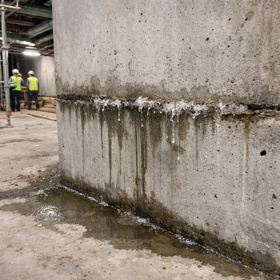
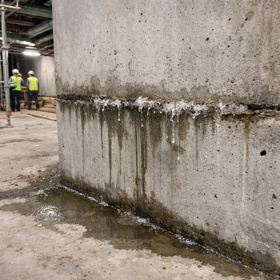
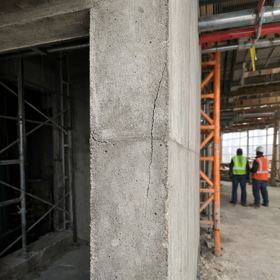
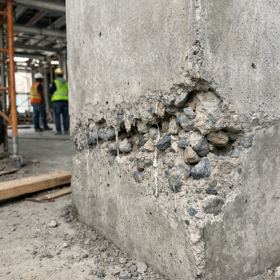
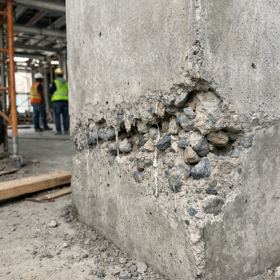
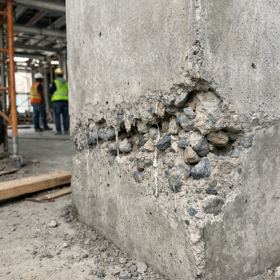
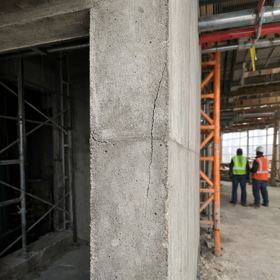
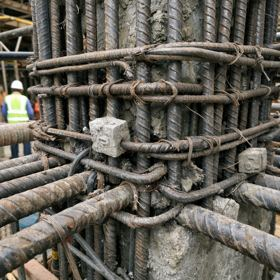
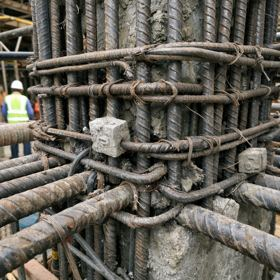
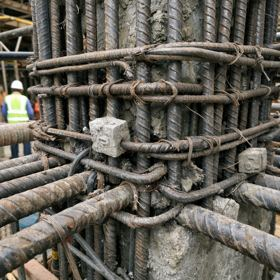
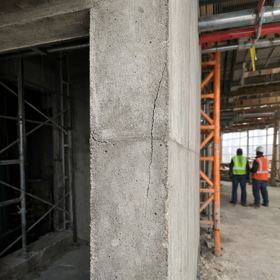
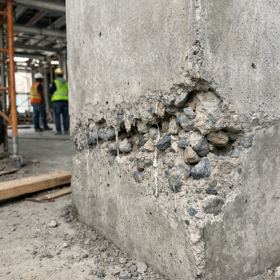
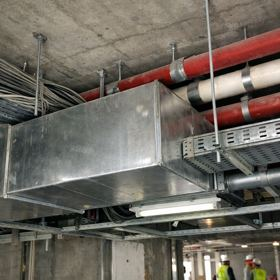
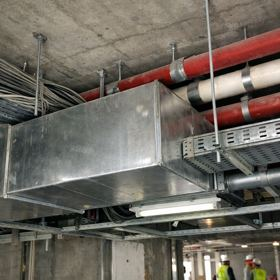
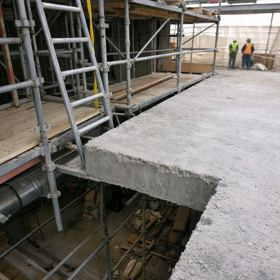
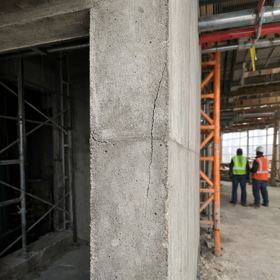
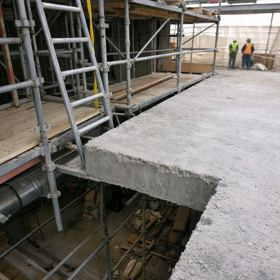
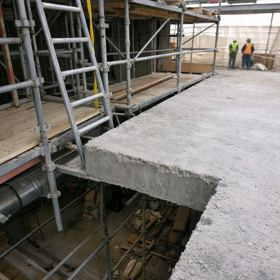
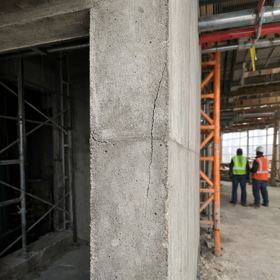
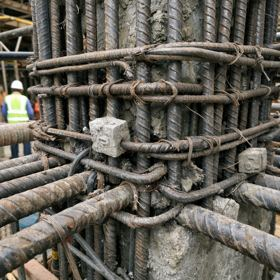
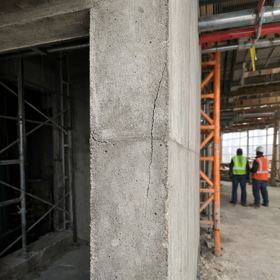
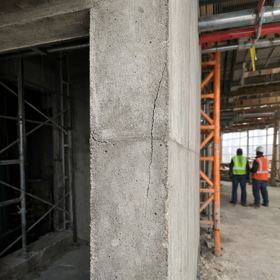
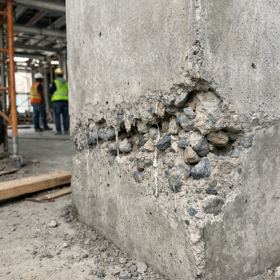
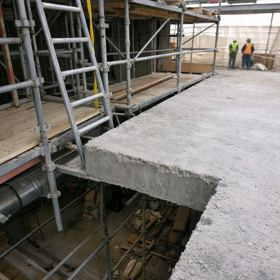

In [2]:
from IPython.display import HTML, display
# Executed output below embeds the top retrieval thumbnails for each offline query.
display(HTML(offline_query_result_html))


## User question and grounded model response

The notebook now presents the response the way the field worker would see it: question first, then a clean grounded answer. The evidence prompt is still stored in the JSON report for auditability, but it is not shown as the user-facing response.

### basement water ingress

**User question:** A photo shows damp staining and active seepage along a basement retaining wall cold joint.

**Query image:** `inc_001_basement_wall_water_ingress_observed_at_cons.png`

**Model response:**

> This looks closest to [INC-001] Basement wall water ingress observed at construction joint (severity: high).
> What I can ground from the local evidence: Active water ingress is visible at the basement wall joint, with staining extending below the suspect construction joint and moisture tracking toward the floor slab edge. No immediate structural distress is evident, but the leakage suggests a compromised waterproofing detail or joint seal failure.
> Likely cause to check: Likely discontinuity in waterproofing membrane, inadequate joint preparation, or failed waterstop/sealant at a construction joint combined with hydrostatic pressure.
> Recommended next actions:
> 1. Mark and photograph the full extent of seepage and note elevation/chainage references
> 2. Inspect the joint detailing, membrane continuity, and any penetrations or tie-hole repairs
> 3. Check adjacent drainage, sump operation, and external water management conditions
> 4. Implement temporary water control measures and isolate any affected electrical or finish-sensitive areas
> 5. Raise a corrective action for waterproofing specialist review and retesting after repair
> Escalate if: Escalate immediately if leakage increases, reaches active electrical equipment, or shows signs of wall movement, cracking, or soil washout.
> Also compare against [INC-006], [INC-002] if the photo does not match the top case.
> Grounding: answered from ret...

### column honeycombing

**User question:** A column face has honeycombing, exposed aggregate, and rough voids after formwork striking.

**Query image:** `inc_002_concrete_column_honeycombing_detected_after_.png`

**Model response:**

> This looks closest to [INC-002] Concrete column honeycombing detected after form removal (severity: high).
> What I can ground from the local evidence: A reinforced concrete column shows honeycombing in the lower lift area following formwork removal. The defect is localized but extends over enough surface area to indicate poor consolidation or leakage during casting, requiring assessment of depth and impact on cover.
> Likely cause to check: Probable inadequate vibration, congested reinforcement impeding flow, grout loss through formwork joints, or improper concrete placement technique.
> Recommended next actions:
> 1. Sound the affected area and carry out a depth assessment by engineer or competent inspector
> 2. Verify reinforcement cover and determine whether structural repair is required
> 3. Review pour sequence, vibration records, and formwork tightness for the affected lift
> 4. Protect the area from impact and restrict loading until disposition is confirmed
> 5. Prepare a repair method statement if patching, epoxy injection, or breakout and reinstatement is needed
> Escalate if: Escalate to structural engineer immediately if defect depth approaches reinforcement, cover is compromised, or multiple columns exhibit similar honeycombing.
> Also compare against [INC-006], [INC-003] if the photo does not match the top case.
> Grounding: answered from retrieved local evidence for [INC-002].
